# 📊 중개사 신뢰도 모델 분석 리포트

이 노트북은 학습드 모델(로지스틱 회귀)의 성능과 특성을 시각적으로 분석하기 위해 작성되었습니다.

### 분석 항목
1. **📉 학습 곡선 (Learning Curve)**: 과적합 여부 확인
2. **🔲 혼동 행렬 (Confusion Matrix)**: 등급별 예측 정확도 및 오분류 패턴
3. **📊 피처 중요도 (Coefficients)**: 모델이 어떤 변수를 중요하게 봤는지
4. **📈 ROC-AUC 곡선**: 클래스별 분류 성능
5. **🐝 SHAP 분석**: 과의 판단 근거 상세 분석

In [1]:
# 1. 환경 설정 및 데이터 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 맞추기 (notebook 위치에서 상위로 이동)
current_path = os.getcwd()
if 'trust_model' in current_path:
    # apps/reco/models/trust_model/pipeline -> SKN18-FINAL-1TEAM
    if 'SKN18-FINAL-1TEAM' in current_path:
         while not current_path.endswith('SKN18-FINAL-1TEAM'):
            current_path = os.path.dirname(current_path)
            if len(current_path) < 5: break
         os.chdir(current_path)
    print(f"📂 작업 디렉토리 변경: {os.getcwd()}")
else:
    print(f"ℹ️ 현재 작업 디렉토리: {os.getcwd()}")


# 데이터 및 모델 경로
FEATURE_PATH = "data/ML/office_features.csv"
TARGET_PATH = "data/ML/office_target.csv"
MODEL_PATH = "apps/reco/models/trust_model/save_models/temp_trained_models.pkl"

# 데이터 로드
if not os.path.exists(FEATURE_PATH):
    print("⚠️ 데이터 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # 1. 전체 데이터 로드
    df_features = pd.read_csv(FEATURE_PATH)
    target_df = pd.read_csv(TARGET_PATH)
    y = target_df['신뢰도등급']

    # 2. [수정] 학습에 사용할 15개 피처만 명시적으로 선택 (Leakage 방지)
    selected_features = [
        "등록매물_log", "총거래활동량_log",
        "총_직원수", "공인중개사수", "공인중개사_비율",
        "운영기간_년", "운영경험_지수", "숙련도_지수", "운영_안정성",
        "대형사무소", "직책_다양성",
        "대표_공인중개사", "대표_법인", "대표_중개인", "대표_중개보조원",
         "중개보조원_비율", "베테랑" # _02_create_features.py 기준 추가된 피처들 포함
    ]
    
    # 실제 파일에 존재하는 컬럼만 교집합으로 선택
    valid_features = [col for col in selected_features if col in df_features.columns]
    
    X = df_features[valid_features].copy()
    
    # 3. 모델 로드
    with open(MODEL_PATH, 'rb') as f:
        model_data = pickle.load(f)
        
    best_model = model_data['models']['LogisticRegression']
    
    # [수정] 피처 이름 업데이트 (모델 학습 당시와 다를 수 있으므로 X.columns 기준)
    feature_names = X.columns.tolist()

    print("\n✅ 데이터 및 모델 로드 완료 (Leakage 컬럼 제외됨)")
    print(f"  - X shape: {X.shape}")
    print(f"  - 사용된 피처 수: {len(feature_names)}")
    print(f"  - y class distribution: {y.value_counts().to_dict()}")

📂 작업 디렉토리 변경: c:\dev\study\eunjeong\SKN18-FINAL-1TEAM

✅ 데이터 및 모델 로드 완료 (Leakage 컬럼 제외됨)
  - X shape: (351, 17)
  - 사용된 피처 수: 17
  - y class distribution: {'B': 140, 'A': 106, 'C': 105}


c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


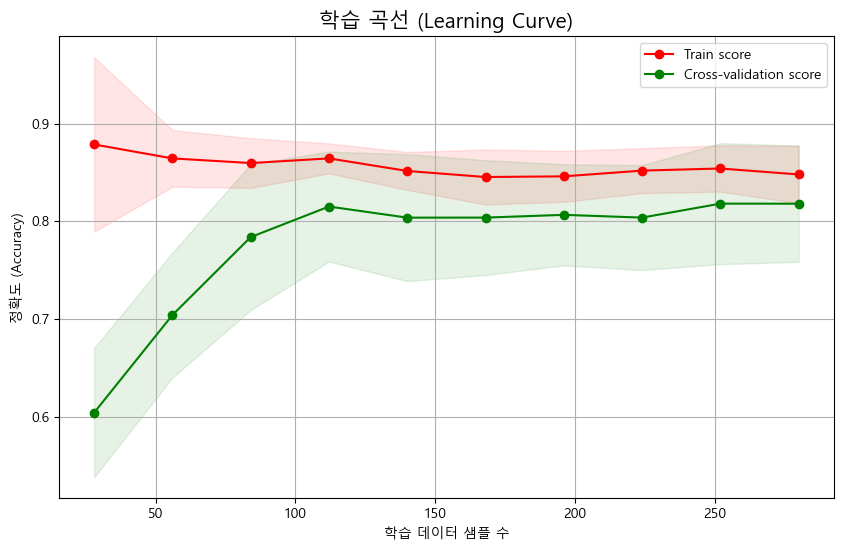

➕ 해석 Point: Train(Red)과 CV(Green) 곡선이 서로 비슷한 높이로 수렴해야 과적합이 없는 것입니다.


In [2]:
# 2. 📉 학습 곡선 (Learning Curve)
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # [수정] 임퓨터 임포트

# 스케일링 포함한 파이프라인 구성
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # [수정] 결측치를 평균값으로 채우는 단계 추가
    ('scaler', StandardScaler()),
    ('clf', best_model)
])

train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Train score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("학습 곡선 (Learning Curve)", fontsize=15)
plt.xlabel("학습 데이터 샘플 수")
plt.ylabel("정확도 (Accuracy)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

print("➕ 해석 Point: Train(Red)과 CV(Green) 곡선이 서로 비슷한 높이로 수렴해야 과적합이 없는 것입니다.")

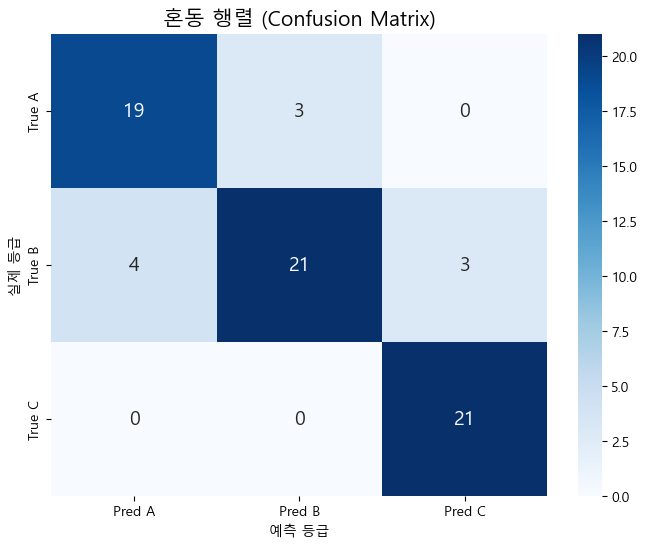

➕ 해석 Point: 대각선(진한 색)에 숫자가 많을수록 좋습니다. B등급을 잘 맞추는지 확인하세요.


In [3]:
# 3. 🔲 혼동 행렬 (Confusion Matrix)
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer  # [추가]

# 데이터 분할 (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 학습 및 예측 (Scaler 적용)
imputer = SimpleImputer(strategy='mean') # [추가] 결측치 처리 객체 생성
scaler = StandardScaler()

# 결측치 채우기
X_train_imputed = imputer.fit_transform(X_train) # [수정] fit_transform
X_test_imputed = imputer.transform(X_test)       # [수정] transform

# 스케일링 (Imputed 데이터 사용)
X_train_scaled = scaler.fit_transform(X_train_imputed) # [수정] imputed 데이터 사용
X_test_scaled = scaler.transform(X_test_imputed)       # [수정] imputed 데이터 사용

best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)


# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred A', 'Pred B', 'Pred C'], 
            yticklabels=['True A', 'True B', 'True C'],
            annot_kws={'size': 14})
plt.title("혼동 행렬 (Confusion Matrix)", fontsize=15)
plt.ylabel('실제 등급')
plt.xlabel('예측 등급')
plt.show()

print("➕ 해석 Point: 대각선(진한 색)에 숫자가 많을수록 좋습니다. B등급을 잘 맞추는지 확인하세요.")

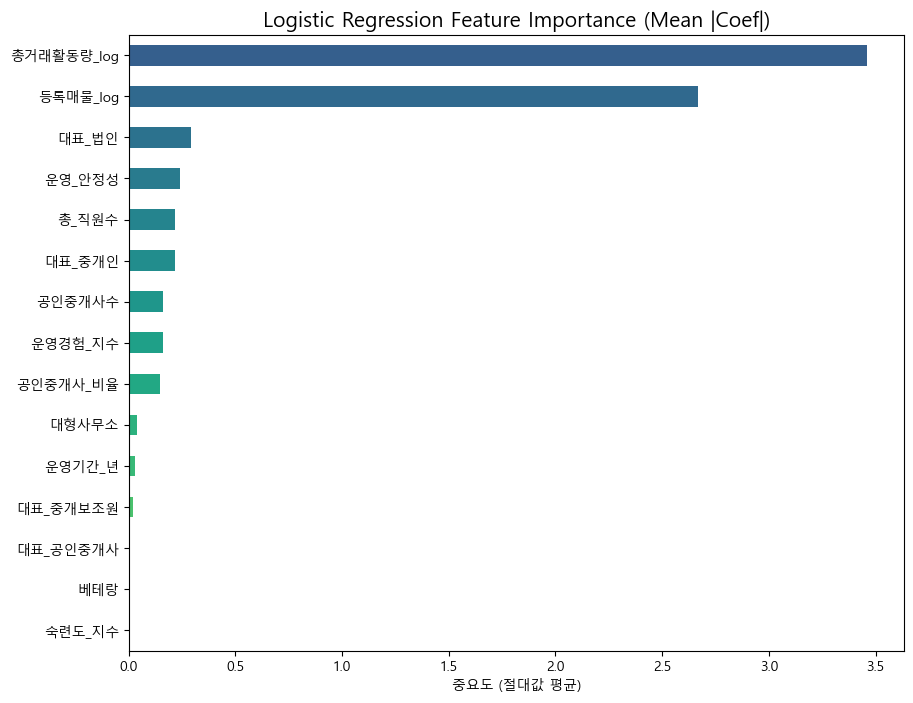

➕ 해석 Point: L1 규제로 인해 0이 된 피처는 모델에서 제외된 것입니다.


In [4]:
# 4. 📊 피처 중요도 (Logistic Regression Coefficients)

coef_abs_mean = np.mean(np.abs(best_model.coef_), axis=0)

# [수정] pickle의 feature_names 대신 현재 X의 컬럼명을 사용
current_feature_names = X.columns.tolist() 

feat_imp = pd.Series(coef_abs_mean, index=current_feature_names).sort_values(ascending=False)

# 상위 15개만 시각화
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp[:15].plot(kind='barh', color=colors[:15]) # 상위 15개만 자르기
plt.title("Logistic Regression Feature Importance (Mean |Coef|)", fontsize=15)
plt.xlabel("중요도 (절대값 평균)")
plt.gca().invert_yaxis()
plt.show()

print("➕ 해석 Point: L1 규제로 인해 0이 된 피처는 모델에서 제외된 것입니다.")

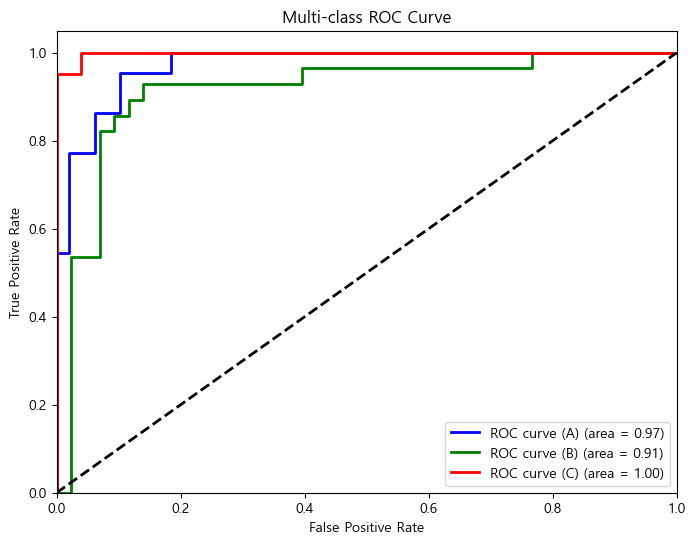

In [5]:
# 5. 📈 ROC-AUC 곡선 (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 클래스 이진화 (A, B, C -> [1,0,0], [0,1,0], [0,0,1])
y_test_bin = label_binarize(y_test, classes=['A', 'B', 'C'])
n_classes = y_test_bin.shape[1]

# 확률 예측
y_score = best_model.predict_proba(X_test_scaled)

# ROC 계산
fpr = dict()
tpr = dict()
roc_auc = dict()
class_labels = ['A', 'B', 'C']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve ({class_labels[i]}) (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [6]:
import shap
import numpy as np

# 1. 계산을 위한 Imputer 처리 (앞선 단계에서 정의되었는지 확인 필요)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_test_imputed = imputer.fit_transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed) # scaler도 정의되어 있어야 함

# 2. SHAP Explainer & 값 계산
# 속도를 위해 Train 데이터 일부만 사용하여 기준점 설정
X_summary = shap.kmeans(X_train_scaled, 10) 
explainer = shap.KernelExplainer(best_model.predict_proba, X_summary)

print("⏳ SHAP 값 계산 중... (잠시만 기다려주세요)")
shap_values = explainer.shap_values(X_test_scaled)
print("✅ 계산 완료!")

⏳ SHAP 값 계산 중... (잠시만 기다려주세요)


  0%|          | 0/71 [00:00<?, ?it/s]

✅ 계산 완료!


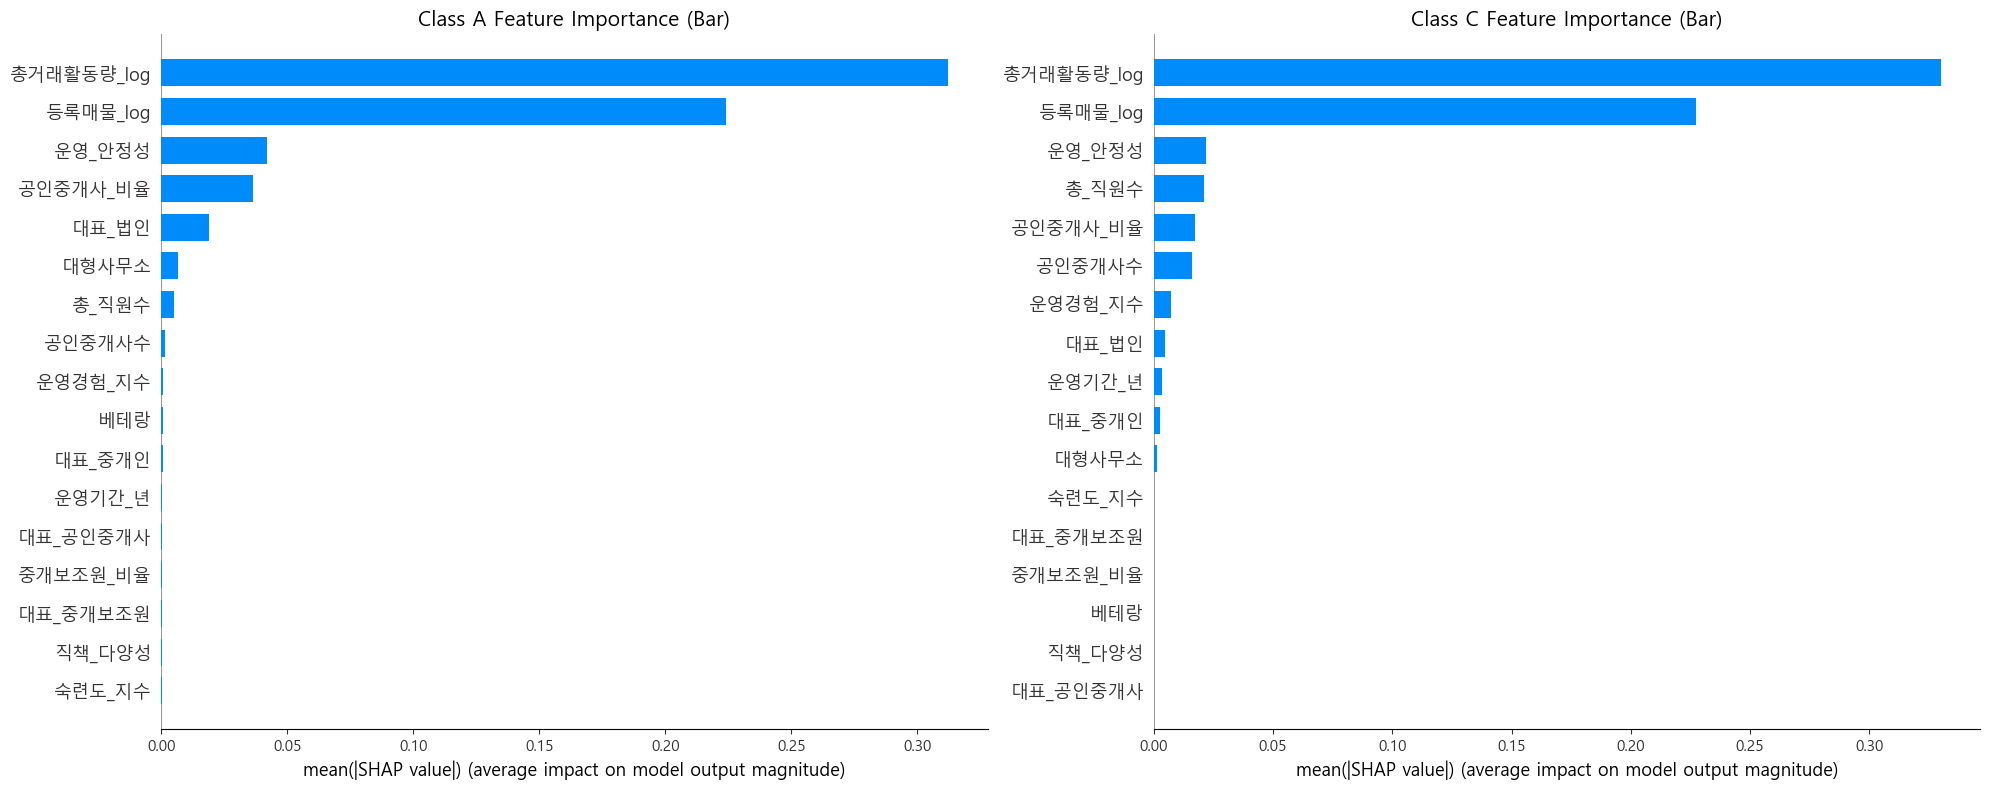

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import shap

# 3차원 배열 변환
shap_values_arr = np.array(shap_values)

# 전체 그림 크기 설정
plt.figure(figsize=(20, 8)) 

# --------------------------
# 첫 번째 그래프: Class A (Bar Type)
# --------------------------
plt.subplot(1, 2, 1)
plt.title("Class A Feature Importance (Bar)", fontsize=15)
# plot_type="bar" 추가
shap.summary_plot(shap_values_arr[:, :, 0], X_test_scaled, feature_names=X.columns.tolist(), plot_type="bar", show=False, plot_size=None)

# --------------------------
# 두 번째 그래프: Class C (Bar Type)
# --------------------------
plt.subplot(1, 2, 2)
plt.title("Class C Feature Importance (Bar)", fontsize=15)
# plot_type="bar" 추가
shap.summary_plot(shap_values_arr[:, :, 2], X_test_scaled, feature_names=X.columns.tolist(), plot_type="bar", show=False, plot_size=None)

plt.tight_layout()
plt.show()